In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df=pd.read_csv('train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [3]:
#Knowing more about data types in our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.value_counts()

,,,,,,,,,,,,count
PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,1
12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,1
873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,1
880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,1


**Identify Data cleaning issues**


1. There are NaN values in Age column
2. We do not require columns like Embarked, Cabin



In [7]:
#Looking for null values
print(df.isnull().values.any())

True


In [9]:
#Filling Age column based on Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [11]:
# Get columns with null values
null_columns = df.columns[df.isnull().any()]
print(null_columns)

Index(['Cabin', 'Embarked'], dtype='object')


In [13]:
#Dropping null columns
df.drop(['Cabin','Embarked'],axis=1,inplace=True)

In [14]:
print(df.isnull().values.any())

False


<Axes: xlabel='Pclass', ylabel='count'>

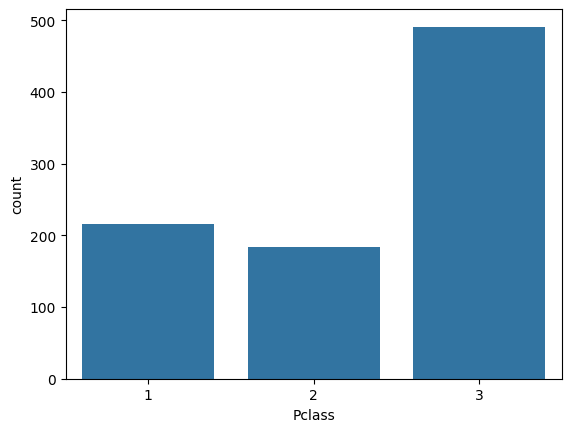

In [15]:
#Number of passengers travelled in each type of Class
sns.countplot(x='Pclass',data=df)

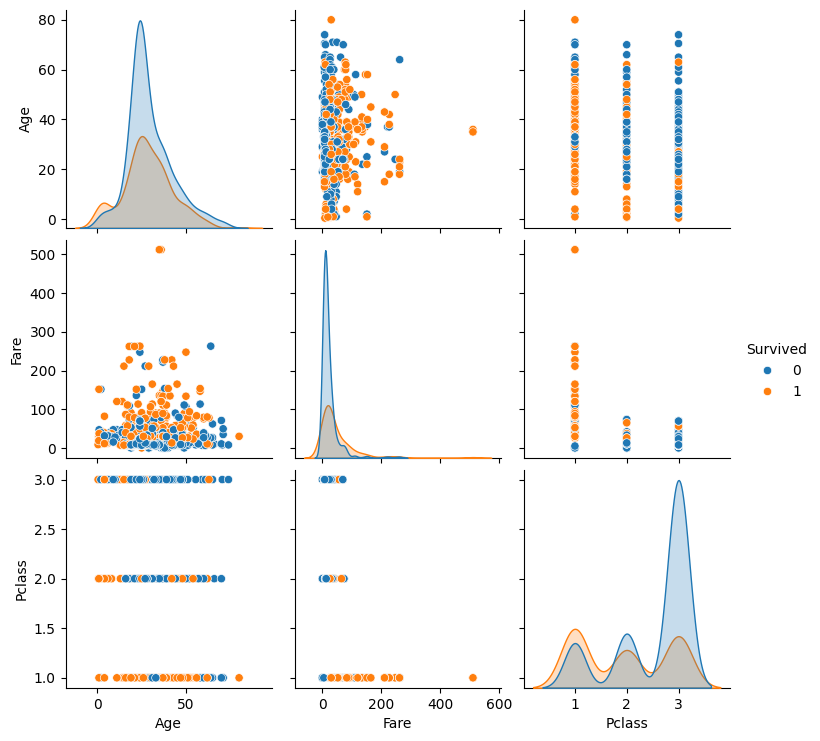

In [16]:
# Pairplot on key numeric columns with 'Survived' as hue
sns.pairplot(df, vars=['Age', 'Fare', 'Pclass'], hue='Survived')

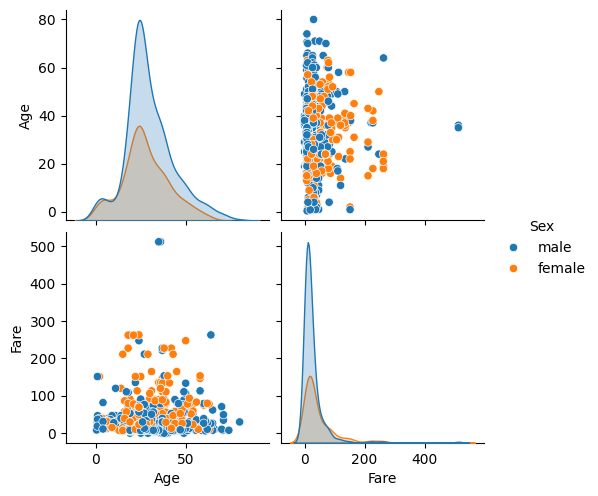

In [17]:
sns.pairplot(df, vars=['Age', 'Fare'], hue='Sex')
# This Seaborn pairplot shows the distribution and relationship between Age and
# Fare in the Titanic dataset, colored by Sex. %% Compute correlation matrix for
# numeric columns

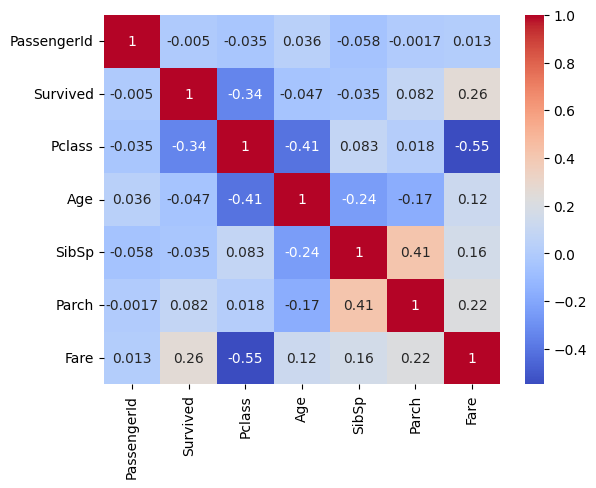

In [18]:
# Compute correlation matrix for numeric columns
corr = df.corr(numeric_only=True)

# Heatmap of correlations
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

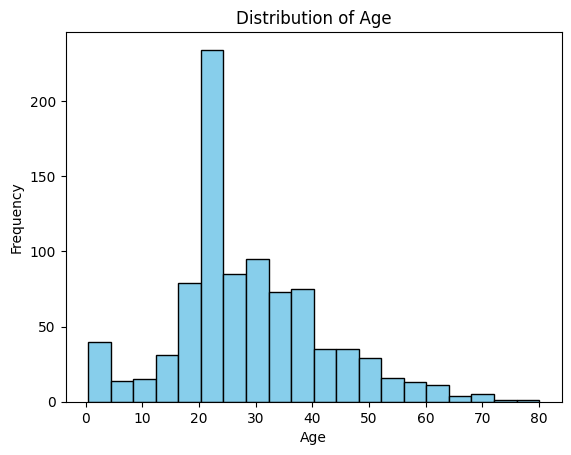

In [19]:
plt.hist(data=df, x='Age', bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

From above outcome, we can see that most of the passengers are between 20-40 years.

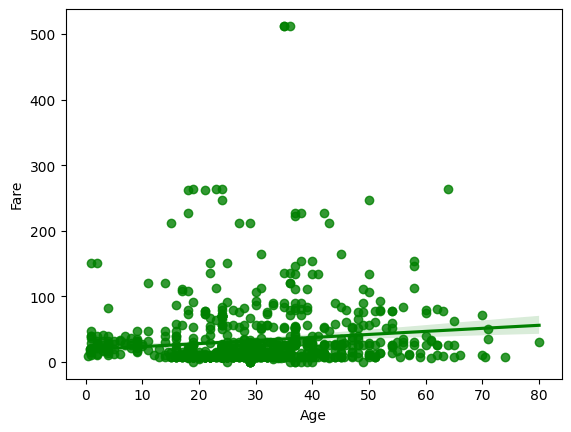

In [20]:
sns.regplot(x='Age', y='Fare', data=df, color='g')
plt.show()

**From above outcome, we found that:**

Most fares cluster at the lower range (under $100), regardless of age.

There are a few outliers with extremely high fares (above $500), particularly in the 30–40 age range.

The regression line has a slightly positive slope, suggesting that fares tend to increase very slightly with age, but the trend is weak.

Data is widely dispersed — no strong linear correlation is visible.Most fares cluster at the lower range (under $100), regardless of age.

There are a few outliers with extremely high fares (above $500), particularly in the 30–40 age range.

The regression line has a slightly positive slope, suggesting that fares tend to increase very slightly with age, but the trend is weak.

Data is widely dispersed — no strong linear correlation is visible.

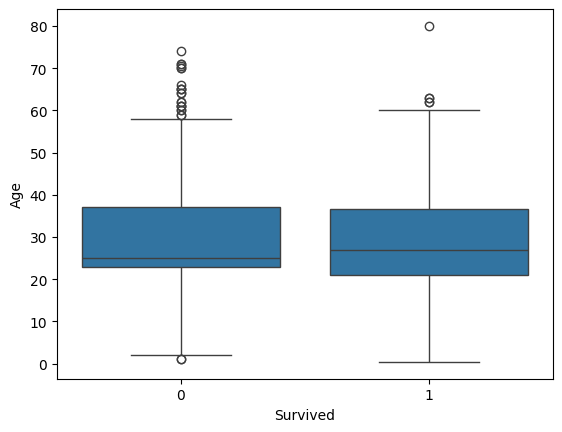

In [21]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

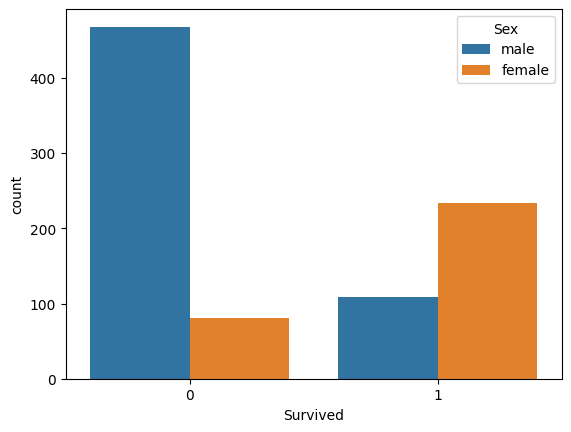

In [22]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.show()

We can conclude from above outcome that most of the female passengers are survived.

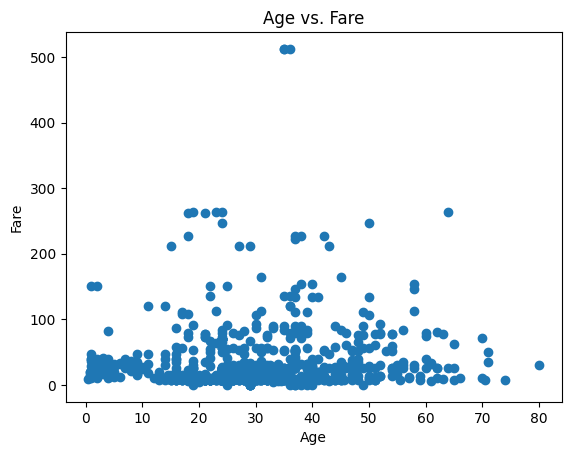

In [23]:
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs. Fare')
plt.show()

We conclude from above that

Most fares are low (under $100) regardless of age.

Age range is broad (0 to ~80 years), with no clear trend linking age and fare.